In [22]:
import numpy as np
import pandas as pd

%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "font.size": 12,
    })


detections_narrow_ET = pd.read_csv("./detection_output/narrow_ET.dat", sep="    ")
detections_narrow_ET_CE = pd.read_csv("./detection_output/narrow_ET_CE.dat", sep="    ")
detections_wide_ET = pd.read_csv("./detection_output/wide_ET.dat", sep="    ")
detections_wide_ET_CE = pd.read_csv("./detection_output/wide_ET_CE.dat", sep="    ")


df_wide_gw = pd.read_csv("../gw/gw_params_wide.dat", sep=" ")

/tmp/ipykernel_21762/4114879158.py:14: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  detections_narrow_ET = pd.read_csv("./detection_output/narrow_ET.dat", sep="    ")
/tmp/ipykernel_21762/4114879158.py:15: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  detections_narrow_ET_CE = pd.read_csv("./detection_output/narrow_ET_CE.dat", sep="    ")
/tmp/ipykernel_21762/4114879158.py:16: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine=

(array([ 6.,  7.,  4.,  8., 12., 15., 18., 14., 11.,  4.]),
 array([1.25792508, 1.30576631, 1.35360753, 1.40144875, 1.44928998,
        1.4971312 , 1.54497242, 1.59281364, 1.64065487, 1.68849609,
        1.73633731]),
 <BarContainer object of 10 artists>)

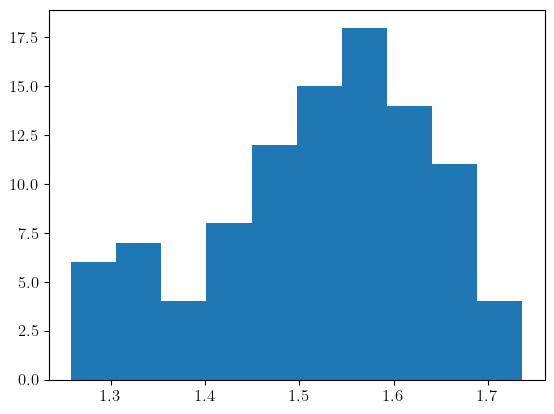

In [34]:
mask = detections_wide_ET_CE["gw_detected"].astype(bool) & (detections_wide_ET_CE["redshift"]> 2.5)

plt.hist( (df_wide_gw[mask]["mass_1_source"] * df_wide_gw[mask]["mass_2_source"])**0.6 / (df_wide_gw[mask]["mass_1_source"] + df_wide_gw[mask]["mass_2_source"])**0.2)




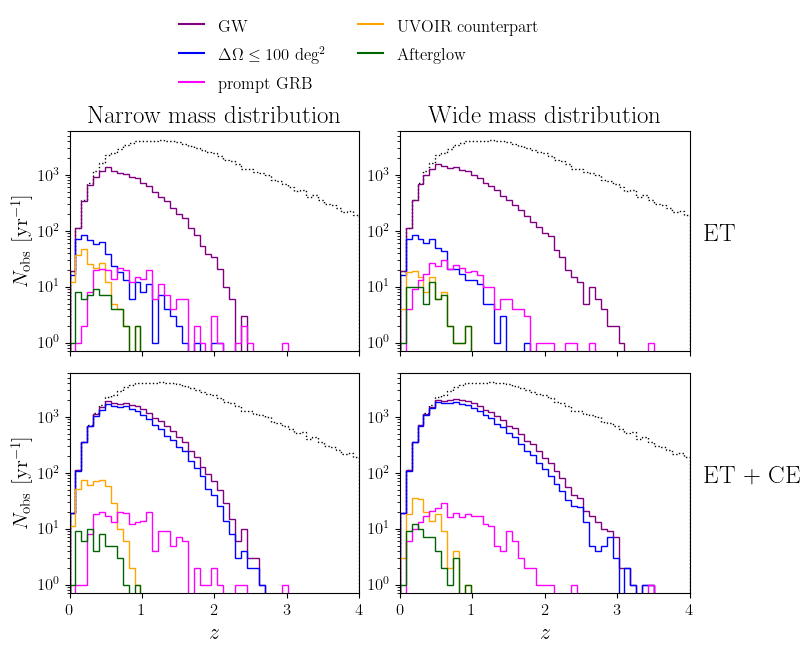

In [4]:
def plot_detections(ax, df):
    
    gw_detected = df["gw_detected"].astype(bool)
    grb_detected = df["grb_detected"].astype(bool)
    kn_detected = np.sum(df[["lsstg", "lssti", "ztfg", "ztfi", "ps1::i", "ps1::g", "ultrasat_custom"]], axis=1) >= 2
    #ztf_detected = (df["ztfg"] + df["ztfi"]) >= 2
    #pstarrs_detected = (df["ps1::i"] + df["ps1::g"]) >= 2
    #ultrasat_detected = (df["ultrasat_custom"]) >= 1
    sky_loc = df["DeltaOmega"] <= 100.
    afterglow_detected = np.sum(df[["radio_afterglow", "opt_afterglow", "xray_afterglow"]], axis=1) >= 1

    bins = np.linspace(0, 4, 50)
    ax.hist(df["redshift"], bins=bins, histtype = "step", color="black", linestyle="dotted")
    ax.hist(df["redshift"][gw_detected], bins=bins, histtype="step", color="purple", label="GW detections")
    ax.hist(df["redshift"][sky_loc], bins=bins, histtype="step", color="blue", label="$\\Delta\\Omega \\leq 100$ deg$^2$")
    ax.hist(df["redshift"][kn_detected], bins=bins, histtype="step", color="orange", label="KN detections")
    #ax.hist(df["redshift"][ztf_detected], bins=np.linspace(0, 4, 50), histtype="step", color="red")
    #ax.hist(df["redshift"][ultrasat_detected], bins=np.linspace(0, 4, 50), histtype="step", color="salmon")
    #ax.hist(df["redshift"][pstarrs_detected], bins=np.linspace(0, 4, 50), histtype="step", color="yellow")
    ax.hist(df["redshift"][grb_detected], bins=bins, histtype="step", color="magenta", label="GRB detections")
    ax.hist(df["redshift"][afterglow_detected], bins=bins, histtype="step", color="darkgreen", label="Afterglow detections")

    ax.set_yscale("log")
    ax.set_ylim((0.7, 6e3))



fig, ax = plt.subplots(2, 2, figsize= (8, 6), sharex=True)
fig.subplots_adjust(hspace=0.1, wspace=0.14)

ax[0,0].set_title("Narrow mass distribution", fontsize=18)
ax[0,0].set_ylabel("$N_{\\mathrm{obs}}$ [yr$^{-1}$]", fontsize=15)
plot_detections(ax[0,0], detections_narrow_ET)

ax[0,1].set_title("Wide mass distribution", fontsize=18)
ax[0,1].text(1.05, 0.5, "ET", rotation=0, transform=ax[0,1].transAxes, fontsize=18)
plot_detections(ax[0,1], detections_wide_ET)


plot_detections(ax[1,0], detections_narrow_ET_CE)
ax[1,0].set_ylabel("$N_{\\mathrm{obs}}$ [yr$^{-1}$]", fontsize=15)
ax[1,0].set_xlim(0, 4)
ax[1,0].set_xlabel("$z$", fontsize=16)


plot_detections(ax[1,1], detections_wide_ET_CE)
ax[1,1].set_xlim(0, 4)
ax[1,1].set_xlabel("$z$", fontsize=16)
ax[1,1].text(1.05, 0.5, "ET + CE", rotation=0, transform=ax[1,1].transAxes, fontsize=18)



labels = [r"GW", r"$\Delta\Omega\leq100$ deg$^2$", "prompt GRB", "UVOIR counterpart", "Afterglow"]

lc1 = plt.plot([], [], color="purple")[0]
lc2 = plt.plot([], [], color="blue")[0]
lc3 = plt.plot([], [], color="magenta")[0]
lc4 = plt.plot([], [], color="orange")[0]
lc5 = plt.plot([], [], color="darkgreen",)[0]
ax[0,0].legend([lc1, lc2, lc3, lc4, lc5], 
                labels, 
                handlelength=1.5, handleheight=1.5,
                bbox_to_anchor=[1., 1.1],loc='lower center',frameon=False, ncol=2)

fig.savefig("../../figures/detections.pdf", dpi=250, bbox_inches="tight")

In [42]:
def print_DeltaOmega_quantiles(detection_df):
    mask = detection_df["gw_detected"].astype(bool)

    print(np.quantile(detection_df["DeltaOmega"][mask], q=[0.5, 0.9]))

print_DeltaOmega_quantiles(detections_narrow_ET_CE)
print_DeltaOmega_quantiles(detections_wide_ET_CE)

print(np.sum(detections_narrow_ET["DeltaOmega"]<=50.31)/ np.sum(detections_narrow_ET["gw_detected"]), np.sum(detections_narrow_ET["DeltaOmega"]<=127.915)/ np.sum(detections_narrow_ET["gw_detected"])) 
print(np.sum(detections_wide_ET["DeltaOmega"]<=48.56)/ np.sum(detections_wide_ET["gw_detected"]), np.sum(detections_wide_ET["DeltaOmega"]<=126.982)/np.sum(detections_wide_ET["gw_detected"])) 

[ 50.31  127.915]
[ 48.56  126.982]
0.021598434677904878 0.0448524984948826
0.02040816326530612 0.03908682116914562


(array([ 421.,  922.,  956., 1128., 1147., 1241., 1254., 1196., 1220.,
        1177.]),
 array([ 0.1  ,  5.121, 10.142, 15.163, 20.184, 25.205, 30.226, 35.247,
        40.268, 45.289, 50.31 ]),
 <BarContainer object of 10 artists>)

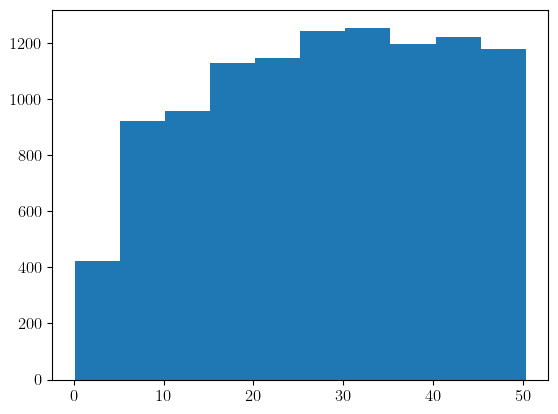

In [46]:
plt.hist(detections_narrow_ET_CE[detections_narrow_ET_CE["DeltaOmega"]<=50.31]["DeltaOmega"])

In [37]:
def print_telt(df):

    print("ztf", np.sum(df["telt_ztf"])/(365*0.5), np.sum(np.sum(df[["ztfg", "ztfi"]], axis=1)>2))
    print("vr", np.sum(df["telt_vr"])/(365*0.5), np.sum(np.sum(df[["lsstg", "lssti"]], axis=1)>2))
    print("pstarrs", np.sum(df["telt_pstarrs"])/(365*0.5), np.sum(np.sum(df[["ps1::g", "ps1::i"]], axis=1)>2))
    print("ultrasat detections", np.sum(df["telt_ultrasat"])/(365), np.sum(df["ultrasat_custom"]))

print_telt(detections_narrow_ET)

ztf 0.03244545915778789 3
vr 0.35163876204972094 139
pstarrs 0.08078386605783863 43
ultrasat detections 0.07574200913242005 28
